[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_3429/4145155509.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


                        word  level  pos  \
0  a (little) bit more about    NaN  NaN   
1         a (whole) range of    NaN  NaN   
2        a (whole) series of    NaN  NaN   
3  a better understanding of    NaN  NaN   
4                 a bit like    NaN  NaN   

                                      definition_url  \
0  https://www.oxfordlearnersdictionaries.com/def...   
1  https://www.oxfordlearnersdictionaries.com/def...   
2  https://www.oxfordlearnersdictionaries.com/def...   
3  https://www.oxfordlearnersdictionaries.com/def...   
4  https://www.oxfordlearnersdictionaries.com/def...   

                                           voice_url  
0  https://www.oxfordlearnersdictionaries.com/med...  
1  https://www.oxfordlearnersdictionaries.com/med...  
2  https://www.oxfordlearnersdictionaries.com/med...  
3  https://www.oxfordlearnersdictionaries.com/med...  
4  https://www.oxfordlearnersdictionaries.com/med...  
Index(['word', 'level', 'pos', 'definition_url', 'voice_url'], dtype

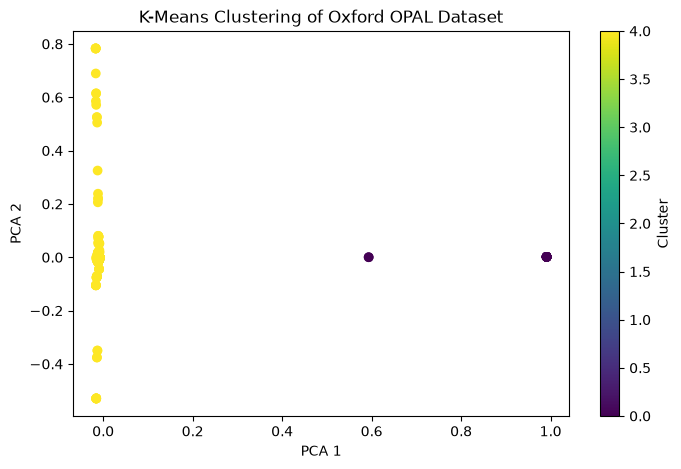


Done! Saved as oxford-opal-clustered.csv


In [1]:
# Install if needed:
# !pip install pandas scikit-learn nltk matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

nltk.download("stopwords")

# 1. Load dataset
df = pd.read_csv("oxford-opal.csv")
print(df.head())
print(df.columns)

# 2. Select text column
# Change this to your actual text column if needed
text_col = df.select_dtypes(include="object").columns[0]

# 3. Clean text
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df[text_col].fillna("").apply(clean_text)

# 4. NLP: TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df["clean_text"])

# 5. K-Means
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 6. Show cluster sizes
print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())

# 7. Show important words in each cluster
terms = tfidf.get_feature_names_out()

for i in range(k):
    words = model.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i}:")
    print(", ".join(terms[words]))

# 8. Visualise clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering of Oxford OPAL Dataset")
plt.colorbar(label="Cluster")
plt.show()

# 9. Save results
df.to_csv("oxford-opal-clustered.csv", index=False)

print("\nDone! Saved as oxford-opal-clustered.csv")